# Decision Trees - Example

Apply a Random Forest classifier, `RandomForest()` to the heart disease dataset.

The data is hosted on UCI https://archive.ics.uci.edu/ml/datasets/Heart+Disease

we will need `load_heart_disease()` from last week `w03-3-filled.ipynb`

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load and prepare the data

**Question:** Can you update the function `load_heart_disease()` to download the file from the url if the file is not on disk?

In [3]:
def load_heart_disease():
    '''Load and pre-process heart disease data
    
    if processed.hungarian.data file is not present.
    
    it will be downloaded from
    https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.hungarian.data
    
    return: data(DataFrame)
    
    '''
    
    import os
    import requests
    
    
    file_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.hungarian.data'
    file_name = file_url.split('/')[-1]
    
    if not os.path.isfile(file_name):
        print('Downloading from {}'.format(file_url))
        r = requests.get(file_url)
        with open(file_name,'wb') as output_file:
            output_file.write(r.content)
        
    data = pd.read_csv(file_name, 
                   na_values='?', 
                   names=[ 'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
                            'restecg', 'thalach', 'exang', 'oldpeak', 'slope',
                            'ca', 'thal', 'num'])
    
    # drop columns with many missing data
    data = data.drop(columns=['slope', 'ca', 'thal'])
    
    # fill in remaining missing data with mean() per column
    data = data.fillna(data.mean())
    
    return data

In [4]:
data = load_heart_disease()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294 entries, 0 to 293
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       294 non-null    int64  
 1   sex       294 non-null    int64  
 2   cp        294 non-null    int64  
 3   trestbps  294 non-null    float64
 4   chol      294 non-null    float64
 5   fbs       294 non-null    float64
 6   restecg   294 non-null    float64
 7   thalach   294 non-null    float64
 8   exang     294 non-null    float64
 9   oldpeak   294 non-null    float64
 10  num       294 non-null    int64  
dtypes: float64(7), int64(4)
memory usage: 25.4 KB


### Create feature matrix and target vector 

In [5]:
X = data.drop(columns='num')
y = data['num']
print(X.shape)
print(y.shape)

(294, 10)
(294,)


### Create training and test sets

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.1,
                                                    stratify=y,
                                                    random_state=31)

print(X_train.shape)
print(X_test.shape)

(264, 10)
(30, 10)


In [7]:
y_train.value_counts()

0    169
1     95
Name: num, dtype: int64

In [8]:
y_test.value_counts()

0    19
1    11
Name: num, dtype: int64

## Apply `RandomForest()` and evaluate the performance 

In [9]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=58)
# model.fit(X_train, y_train)

### Cross validation 

Are we over- or underfitting?

Using `cross_val_score()`

In [10]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X_train, y_train, cv=5)
scores

array([0.83018868, 0.8490566 , 0.81132075, 0.79245283, 0.80769231])

In [11]:
scores.mean()

0.8181422351233673

Using `cross_validate()`

In [12]:
from sklearn.model_selection import cross_validate
scores = cross_validate(model, X_train, y_train, cv=5, 
                        scoring='accuracy',
                       return_train_score=True)
scores

{'fit_time': array([0.14958906, 0.11834598, 0.1176939 , 0.11828589, 0.1175282 ]),
 'score_time': array([0.0110929 , 0.0111382 , 0.01089311, 0.01090693, 0.01073599]),
 'test_score': array([0.83018868, 0.8490566 , 0.81132075, 0.79245283, 0.80769231]),
 'train_score': array([1., 1., 1., 1., 1.])}

In [13]:
for label_pair in [ ('train_score', 'train_score'), ('test_score', 'validation_score')]:
    print('{}= {:.3f}'.format(label_pair[1], scores[label_pair[0]].mean()))

train_score= 1.000
validation_score= 0.818


Likely overfitting and would need a less complex model to increase validation accuracy.

Would could use: Pre-pruning by reducing maximum depth. More trees, or smaller max_features to reduce overfitting.

### Grid search

To select which of the parameter combinations work best, we will use grid search.

We want to check that the optimal parameters are not at the edge of our search interval.

In [25]:
from sklearn.model_selection import GridSearchCV

param_grid = {'n_estimators': [20, 50, 100, 200],
             'max_depth': [1, 2, 3, 5, 7],
             'max_features': ['auto', 'log2', None]}

grid = GridSearchCV(model, param_grid, cv=5)

In [26]:
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=58),
             param_grid={'max_depth': [1, 2, 3, 5, 7],
                         'max_features': ['auto', 'log2', None],
                         'n_estimators': [20, 50, 100, 200]})

In [27]:
grid.best_params_

{'max_depth': 2, 'max_features': 'auto', 'n_estimators': 50}

In [28]:
grid.best_score_

0.8294629898403484

Note that this cross-validation score is slightly lower than `LogisticRegression()`. Therefore, between the two, we would select `LogisticRegression()`.

Let's assume we did not have another model, this is it. We would want to see final performance on the test set.

### Retrain the *best* model on all the training data

In [18]:
# model = grid.best_estimator_
# model.fit(X_train, y_train)


### Retrain model on all the training data

In [19]:
model.fit(X_train, y_train)

RandomForestClassifier(random_state=58)

### Compare training and test accuracy


In [20]:
model.score(X_train, y_train)

1.0

In [21]:
model.score(X_test, y_test)

0.8

### The confusion matrix on the test set 

Your thoughts?

Text(91.68, 0.5, 'true value')

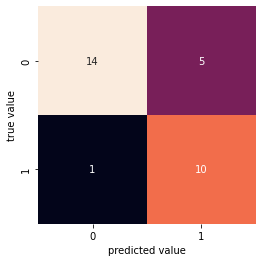

In [22]:
from sklearn.metrics import confusion_matrix

mat = confusion_matrix(y_test, model.predict(X_test))

sns.heatmap(mat, square=True, annot=True, cbar=False)
plt.xlabel('predicted value')
plt.ylabel('true value')

We make different mistakes than with `LogisticRegression()`. 

It might be time to go back to the features, or try a gradient boosted tree.

### Summarize the different scores 

In [23]:
scores = cross_validate(model, X_train, y_train, cv=5, 
                        scoring='accuracy',
                       return_train_score=True)

print('training accuracy (all data) {:.3f}'.format(model.score(X_train, y_train)))

print('training accuracy (cross-validation) {:.3f}'.format(scores['train_score'].mean()))

print('validation accuracy (cross-validation) {:.3f}'.format(scores['test_score'].mean()))

print('test accuracy (new data) {:.3f}'.format(model.score(X_test, y_test)))

training accuracy (all data) 1.000
training accuracy (cross-validation) 1.000
validation accuracy (cross-validation) 0.818
test accuracy (new data) 0.800
